In [27]:
#1)Hypothesis Generation

#-Traffic will increase as the years pass by
#-Traffic will be high from May to October
#-Traffic on weekdays will be more
#-Traffic during the peak hours will be high

In [6]:
#2) Getting the system ready and loading the data

In [10]:
#we will import all the packages which will be used throughout the notebook.
import pandas as pd          
import numpy as np          # For mathematical calculations 
import matplotlib.pyplot as plt  # For plotting graphs 
from datetime import datetime    # To access datetime 
from pandas import Series        # To work on series 
%matplotlib inline 
import warnings 

In [11]:
#Now let’s read the train and test data
train=pd.read_csv(r"C:\Users\Aditi\Traffic_prediction_using_Time_Series\Train_SU63ISt.csv") 
test=pd.read_csv(r"C:\Users\Aditi\Traffic_prediction_using_Time_Series\Test_0qrQsBZ.csv")

In [12]:
#Let’s make a copy of train and test data so that even if we do changes in these dataset we do not lose the original dataset.
train_original=train.copy() 
test_original=test.copy()

In [13]:
#3) Dataset Structure and Content

In [14]:
train.columns, test.columns

(Index(['ID', 'Datetime', 'Count'], dtype='object'),
 Index(['ID', 'Datetime'], dtype='object'))

In [15]:
#Let’s look at the data types of each feature.

train.dtypes, test.dtypes

(ID           int64
 Datetime    object
 Count        int64
 dtype: object,
 ID           int64
 Datetime    object
 dtype: object)

In [16]:
#Now we will see the shape of the dataset.

train.shape, test.shape

((18288, 3), (5112, 2))

In [17]:
#4) Feature Extraction

#We will extract the time and date from the Datetime.
#We have seen earlier that the data type of Datetime is object.
#So first of all we have to change the data type to datetime format otherwise we can not extract features from it.

In [18]:
train['Datetime'] = pd.to_datetime(train.Datetime,format='%d-%m-%Y %H:%M')
test['Datetime'] = pd.to_datetime(test.Datetime,format='%d-%m-%Y %H:%M')
train_original['Datetime'] = pd.to_datetime(train_original.Datetime,format='%d-%m-%Y %H:%M')
test_original['Datetime'] = pd.to_datetime(test_original.Datetime,format='%d-%m-%Y %H:%M')

In [19]:
#We made some hypothesis for the effect of hour, day, month and year on the passenger count.
#So, let’s extract the year, month, day and hour from the Datetime to validate our hypothesis.
for i in (train, test, test_original, train_original):
    i['year']=i.Datetime.dt.year 
    i['month']=i.Datetime.dt.month 
    i['day']=i.Datetime.dt.day
    i['Hour']=i.Datetime.dt.hour 

In [20]:
#We made a hypothesis for the traffic pattern on weekday and weekend as well. 
#So, let’s make a weekend variable to visualize the impact of weekend on traffic.

In [21]:
#We will first extract the day of week from Datetime and then based on the values we will assign whether the day is a weekend or not.
#Values of 5 and 6 represents that the days are weekend.

train['day of week']=train['Datetime'].dt.dayofweek 
temp = train['Datetime']

In [22]:
train

,ID,Datetime,Count,year,month,day,Hour,day of week
0,0,2012-08-25 00:00:00,8,2012,8,25,0,5
1,1,2012-08-25 01:00:00,2,2012,8,25,1,5
2,2,2012-08-25 02:00:00,6,2012,8,25,2,5
3,3,2012-08-25 03:00:00,2,2012,8,25,3,5
4,4,2012-08-25 04:00:00,2,2012,8,25,4,5
...,...,...,...,...,...,...,...,...
18283,18283,2014-09-25 19:00:00,868,2014,9,25,19,3
18284,18284,2014-09-25 20:00:00,732,2014,9,25,20,3
18285,18285,2014-09-25 21:00:00,702,2014,9,25,21,3
18286,18286,2014-09-25 22:00:00,580,2014,9,25,22,3


In [23]:
temp

0       2012-08-25 00:00:00
1       2012-08-25 01:00:00
2       2012-08-25 02:00:00
3       2012-08-25 03:00:00
4       2012-08-25 04:00:00
                ...        
18283   2014-09-25 19:00:00
18284   2014-09-25 20:00:00
18285   2014-09-25 21:00:00
18286   2014-09-25 22:00:00
18287   2014-09-25 23:00:00
Name: Datetime, Length: 18288, dtype: datetime64[ns]

In [24]:
#Let’s assign 1 if the day of week is a weekend and 0 if the day of week in not a weekend.

def applyer(row):
    if row.dayofweek == 5 or row.dayofweek == 6:
        return 1
    else:
        return 0 
temp2 = train['Datetime'].apply(applyer) 
train['weekend']=temp2

In [25]:
train

,ID,Datetime,Count,year,month,day,Hour,day of week,weekend
0,0,2012-08-25 00:00:00,8,2012,8,25,0,5,1
1,1,2012-08-25 01:00:00,2,2012,8,25,1,5,1
2,2,2012-08-25 02:00:00,6,2012,8,25,2,5,1
3,3,2012-08-25 03:00:00,2,2012,8,25,3,5,1
4,4,2012-08-25 04:00:00,2,2012,8,25,4,5,1
...,...,...,...,...,...,...,...,...,...
18283,18283,2014-09-25 19:00:00,868,2014,9,25,19,3,0
18284,18284,2014-09-25 20:00:00,732,2014,9,25,20,3,0
18285,18285,2014-09-25 21:00:00,702,2014,9,25,21,3,0
18286,18286,2014-09-25 22:00:00,580,2014,9,25,22,3,0


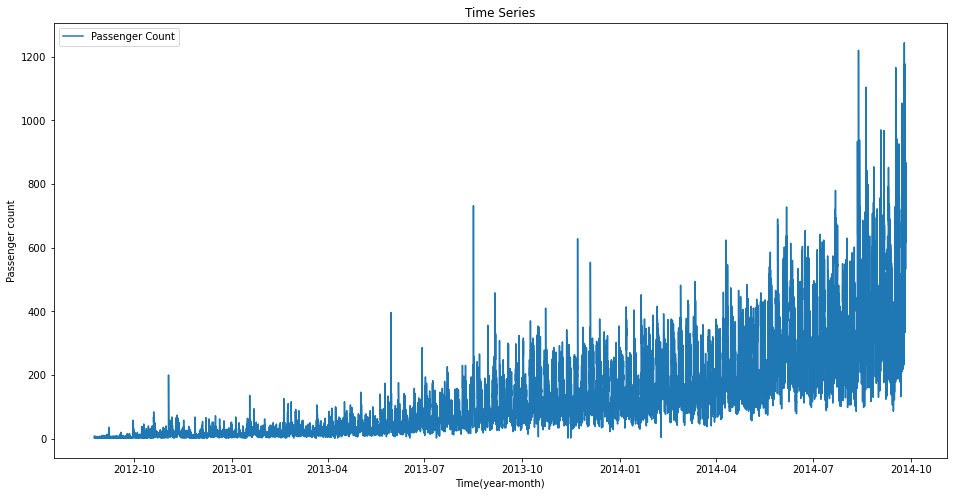

In [26]:
#Let’s look at the time series.

train.index = train['Datetime'] # indexing the Datetime to get the time period on the x-axis. 
df=train.drop('ID',1)           # drop ID variable to get only the Datetime on x-axis. 
ts = df['Count'] 
plt.figure(figsize=(16,8)) 
plt.plot(ts, label='Passenger Count') 
plt.title('Time Series') 
plt.xlabel("Time(year-month)") 
plt.ylabel("Passenger count") 
plt.legend(loc='best')

In [28]:
#5) Exploratory Analysis

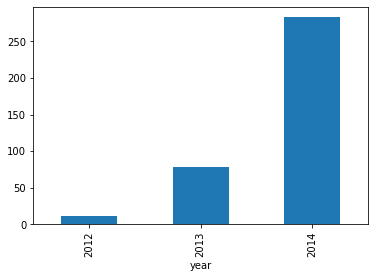

In [29]:
#Our first hypothesis was traffic will increase as the years pass by. So let’s look at yearly passenger count.

train.groupby('year')['Count'].mean().plot.bar()

#(We see an exponential growth in the traffic with respect to year which validates our hypothesis.)

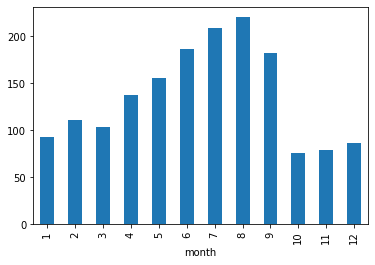

In [30]:
#Our second hypothesis was about increase in traffic from May to October. So, let’s see the relation between count and month.

train.groupby('month')['Count'].mean().plot.bar()

#(Here we see a decrease in the mean of passenger count in last three months. This does not look right.)

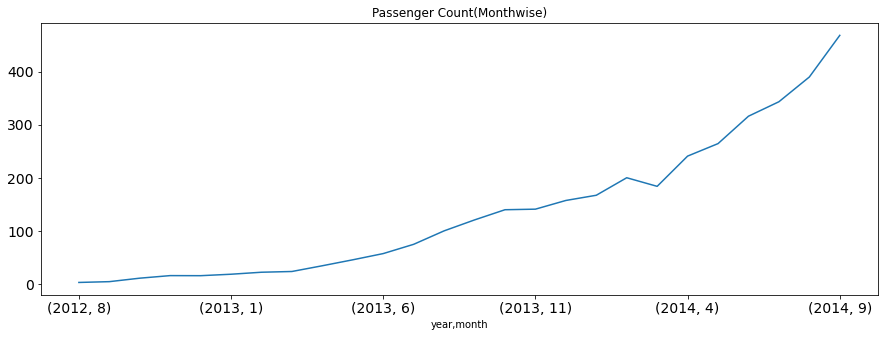

In [31]:
# Let’s look at the monthly mean of each year separately.

temp=train.groupby(['year', 'month'])['Count'].mean() 
temp.plot(figsize=(15,5), title= 'Passenger Count(Monthwise)', fontsize=14)

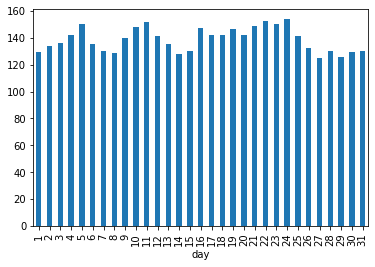

In [32]:
#Let’s look at the daily mean of passenger count.

train.groupby('day')['Count'].mean().plot.bar()

#(We are not getting much insights from day wise count of the passengers.)

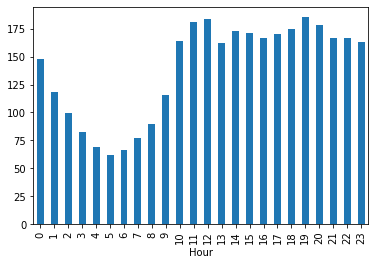

In [33]:
train.groupby('Hour')['Count'].mean().plot.bar()

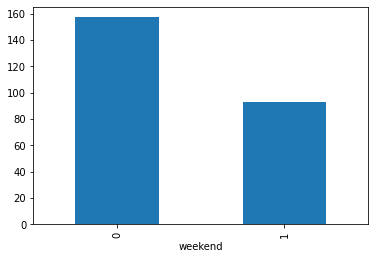

In [34]:
#Let’s try to validate our hypothesis in which we assumed that the traffic will be more on weekdays.

train.groupby('weekend')['Count'].mean().plot.bar()

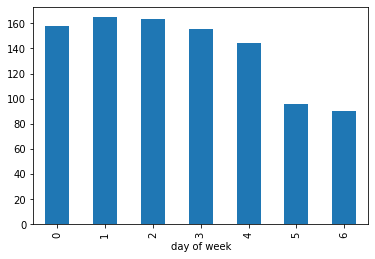

In [35]:
#Now we will try to look at the day wise passenger count.
#Note - 0 is the starting of the week, i.e., 0 is Monday and 6 is Sunday.

train.groupby('day of week')['Count'].mean().plot.bar()

#( passenger count is less for saturday and sunday as compared to the other days of the week. )

In [36]:
#we will look at basic modeling techniques. 
#Before that we will drop the ID variable as it has nothing to do with the passenger count.

train=train.drop('ID',1)

In [37]:
train

,Datetime,Count,year,month,day,Hour,day of week,weekend
Datetime,,,,,,,,
2012-08-25 00:00:00,2012-08-25 00:00:00,8,2012,8,25,0,5,1
2012-08-25 01:00:00,2012-08-25 01:00:00,2,2012,8,25,1,5,1
2012-08-25 02:00:00,2012-08-25 02:00:00,6,2012,8,25,2,5,1
2012-08-25 03:00:00,2012-08-25 03:00:00,2,2012,8,25,3,5,1
2012-08-25 04:00:00,2012-08-25 04:00:00,2,2012,8,25,4,5,1
...,...,...,...,...,...,...,...,...
2014-09-25 19:00:00,2014-09-25 19:00:00,868,2014,9,25,19,3,0
2014-09-25 20:00:00,2014-09-25 20:00:00,732,2014,9,25,20,3,0
2014-09-25 21:00:00,2014-09-25 21:00:00,702,2014,9,25,21,3,0


In [38]:
#As we have seen that there is a lot of noise in the hourly time series
#we will aggregate the hourly time series to daily, weekly, and monthly time series to reduce the noise and make it more stable and hence would be easier for a model to learn.

train.Timestamp = pd.to_datetime(train.Datetime,format='%d-%m-%Y %H:%M') 
train.index = train.Timestamp 
# Hourly time series 
hourly = train.resample('H').mean() 
# Converting to daily mean 
daily = train.resample('D').mean() 
# Converting to weekly mean 
weekly = train.resample('W').mean() 
# Converting to monthly mean 
monthly = train.resample('M').mean()

c:\users\aditi\appdata\local\programs\python\python36\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  after removing the cwd from sys.path.


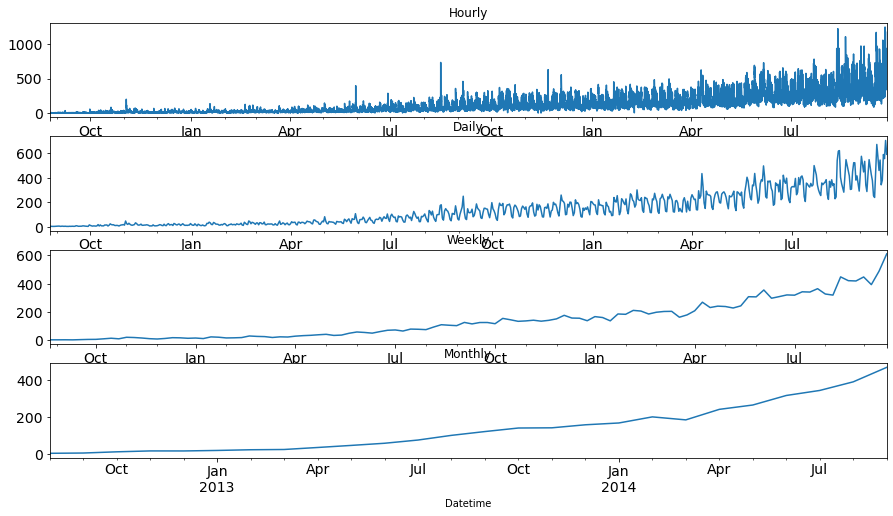

In [45]:
#Let’s look at the hourly, daily, weekly and monthly time series.

fig, axs = plt.subplots(4,1) 
hourly.Count.plot(figsize=(15,8), title= 'Hourly', fontsize=14, ax=axs[0]) 
daily.Count.plot(figsize=(15,8), title= 'Daily', fontsize=14, ax=axs[1]) 
weekly.Count.plot(figsize=(15,8), title= 'Weekly', fontsize=14, ax=axs[2]) 
monthly.Count.plot(figsize=(15,8), title= 'Monthly', fontsize=14, ax=axs[3]) 
plt.show()

In [46]:
#We can see that the time series is becoming more and more stable when we are aggregating it on daily, weekly and monthly basis.
#But it would be difficult to convert the monthly and weekly predictions to hourly predictions,as first we have to convert the monthly predictions to weekly, weekly to daily and daily to hourly predictions, which will become very expanded process.
#So, we will work on the daily time series.

In [48]:
test.Timestamp = pd.to_datetime(test.Datetime,format='%d-%m-%Y %H:%M') 
test.index = test.Timestamp  

# Converting to daily mean 
test = test.resample('D').mean() 

train.Timestamp = pd.to_datetime(train.Datetime,format='%d-%m-%Y %H:%M') 
train.index = train.Timestamp 

# Converting to daily mean 
train = train.resample('D').mean()

c:\users\aditi\appdata\local\programs\python\python36\lib\site-packages\ipykernel_launcher.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  """Entry point for launching an IPython kernel.


In [49]:
#For this course, We will be using a time based split explained below.

#a) Splitting the data into training and validation part

In [51]:
#The starting date of the dataset is 25-08-2012 as we have seen in the exploration part and the end date is 25-09-2014.

Train=train.loc['2012-08-25':'2014-06-24'] 
valid=train.loc['2014-06-25':'2014-09-25']

In [52]:
valid

,Count,year,month,day,Hour,day of week,weekend
Datetime,,,,,,,
2014-06-25,353.666667,2014.0,6.0,25.0,11.5,2.0,0.0
2014-06-26,395.250000,2014.0,6.0,26.0,11.5,3.0,0.0
2014-06-27,282.333333,2014.0,6.0,27.0,11.5,4.0,0.0
2014-06-28,218.250000,2014.0,6.0,28.0,11.5,5.0,1.0
2014-06-29,196.250000,2014.0,6.0,29.0,11.5,6.0,1.0
...,...,...,...,...,...,...,...
2014-09-21,379.250000,2014.0,9.0,21.0,11.5,6.0,1.0
2014-09-22,588.166667,2014.0,9.0,22.0,11.5,0.0,0.0
2014-09-23,554.333333,2014.0,9.0,23.0,11.5,1.0,0.0


In [53]:
Train

,Count,year,month,day,Hour,day of week,weekend
Datetime,,,,,,,
2012-08-25,3.166667,2012.0,8.0,25.0,11.5,5.0,1.0
2012-08-26,3.666667,2012.0,8.0,26.0,11.5,6.0,1.0
2012-08-27,2.583333,2012.0,8.0,27.0,11.5,0.0,0.0
2012-08-28,2.416667,2012.0,8.0,28.0,11.5,1.0,0.0
2012-08-29,2.500000,2012.0,8.0,29.0,11.5,2.0,0.0
...,...,...,...,...,...,...,...
2014-06-20,379.916667,2014.0,6.0,20.0,11.5,4.0,0.0
2014-06-21,220.083333,2014.0,6.0,21.0,11.5,5.0,1.0
2014-06-22,230.833333,2014.0,6.0,22.0,11.5,6.0,1.0


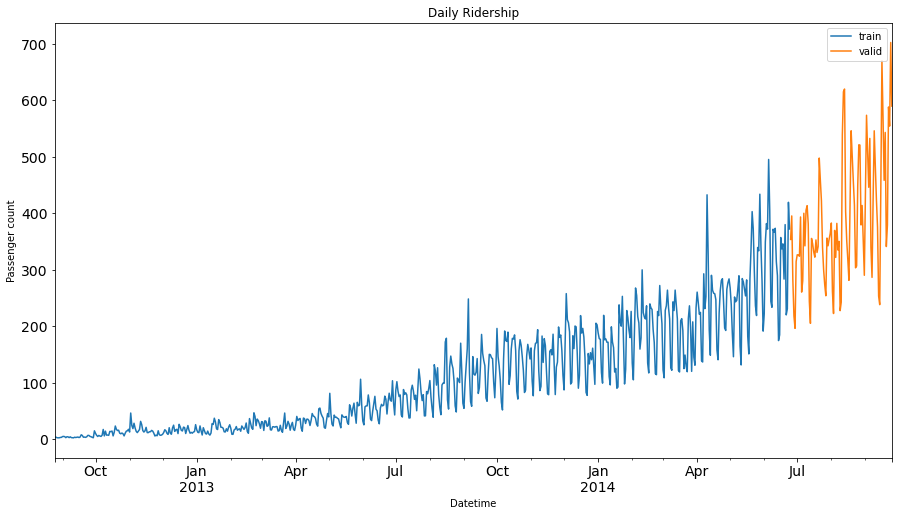

In [55]:
#Now we will look at how the train and validation part has been divided.

Train.Count.plot(figsize=(15,8), title= 'Daily Ridership', fontsize=14, label='train') 
valid.Count.plot(figsize=(15,8), title= 'Daily Ridership', fontsize=14, label='valid') 
plt.xlabel("Datetime") 
plt.ylabel("Passenger count") 
plt.legend(loc='best') 
plt.show()

#(Here the blue part represents the train data and the orange part represents the validation data.)

In [56]:
#We will look at various models now to forecast the time series . Methods which we will be discussing for the forecasting are:

#i) Naive Approach
#ii) Moving Average
#iii) Simple Exponential Smoothing
#iv) Holt’s Linear Trend Model

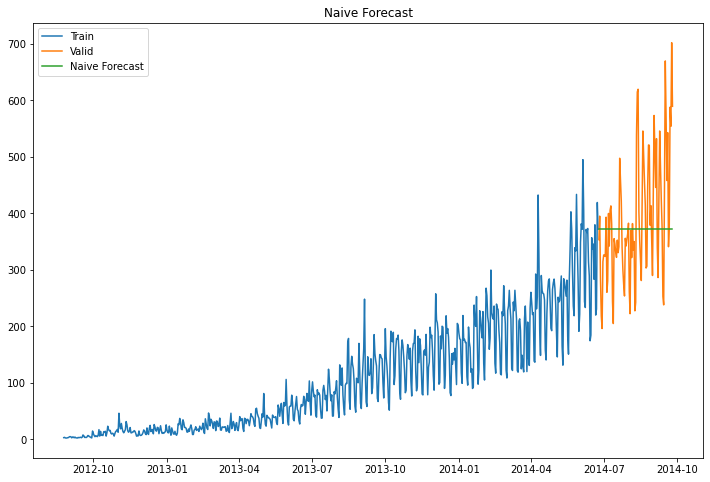

In [57]:
#i) Naive Approach

dd= np.asarray(Train.Count) 
y_hat = valid.copy() 
y_hat['naive'] = dd[len(dd)-1] 
plt.figure(figsize=(12,8)) 
plt.plot(Train.index, Train['Count'], label='Train') 
plt.plot(valid.index,valid['Count'], label='Valid') 
plt.plot(y_hat.index,y_hat['naive'], label='Naive Forecast') 
plt.legend(loc='best') 
plt.title("Naive Forecast") 
plt.show()

In [58]:
from sklearn.metrics import mean_squared_error 
from math import sqrt 
rms = sqrt(mean_squared_error(valid.Count, y_hat.naive)) 
print(rms)

111.79050467496724


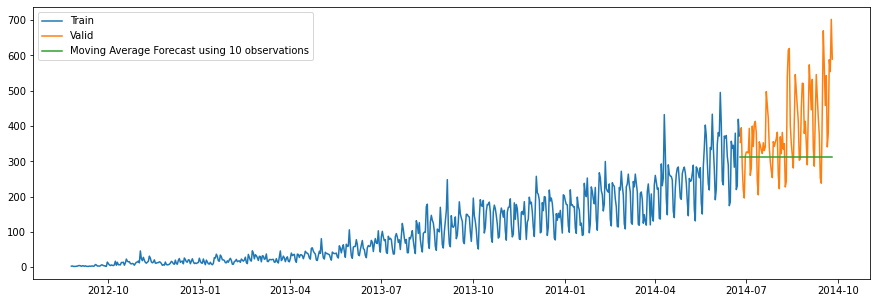

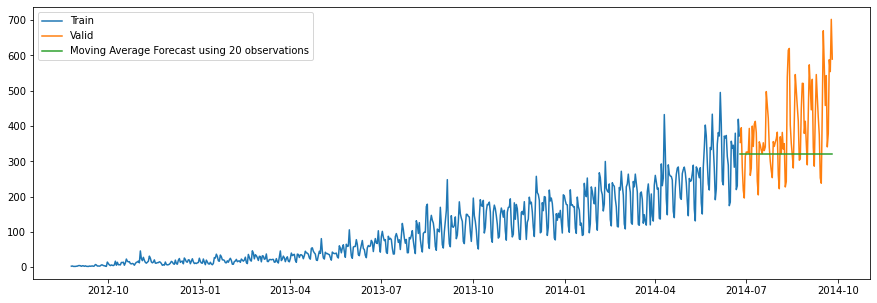

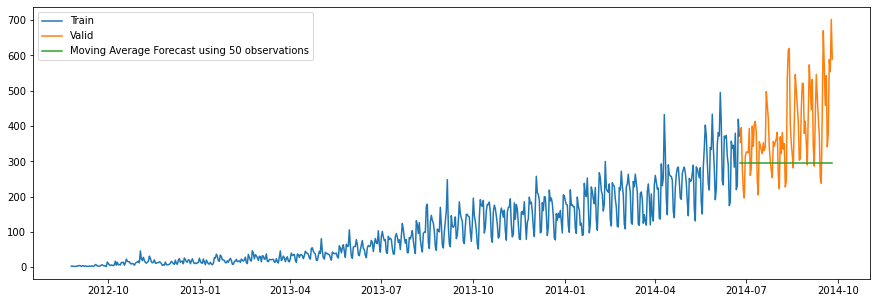

In [59]:
#ii) Moving Average

y_hat_avg = valid.copy() 
y_hat_avg['moving_avg_forecast'] = Train['Count'].rolling(10).mean().iloc[-1] # average of last 10 observations. 
plt.figure(figsize=(15,5)) 
plt.plot(Train['Count'], label='Train') 
plt.plot(valid['Count'], label='Valid') 
plt.plot(y_hat_avg['moving_avg_forecast'], label='Moving Average Forecast using 10 observations') 
plt.legend(loc='best') 
plt.show() 
y_hat_avg = valid.copy() 
y_hat_avg['moving_avg_forecast'] = Train['Count'].rolling(20).mean().iloc[-1] # average of last 20 observations. 
plt.figure(figsize=(15,5)) 
plt.plot(Train['Count'], label='Train') 
plt.plot(valid['Count'], label='Valid') 
plt.plot(y_hat_avg['moving_avg_forecast'], label='Moving Average Forecast using 20 observations') 
plt.legend(loc='best') 
plt.show() 
y_hat_avg = valid.copy() 
y_hat_avg['moving_avg_forecast'] = Train['Count'].rolling(50).mean().iloc[-1] # average of last 50 observations. 
plt.figure(figsize=(15,5)) 
plt.plot(Train['Count'], label='Train') 
plt.plot(valid['Count'], label='Valid') 
plt.plot(y_hat_avg['moving_avg_forecast'], label='Moving Average Forecast using 50 observations') 
plt.legend(loc='best') 
plt.show()

In [60]:
rms = sqrt(mean_squared_error(valid.Count, y_hat_avg.moving_avg_forecast)) 
print(rms)

144.19175679986802


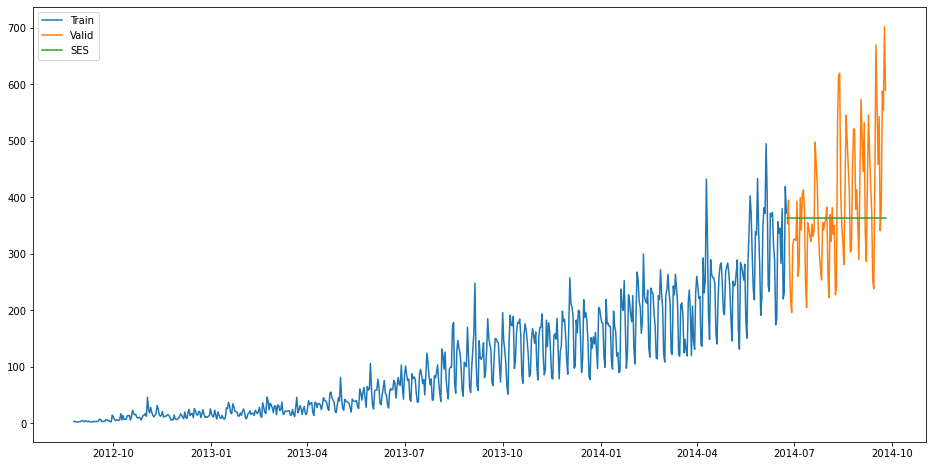

In [63]:
#iii) Simple Exponential Smoothing

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt 
y_hat_avg = valid.copy() 
fit2 = SimpleExpSmoothing(np.asarray(Train['Count'])).fit(smoothing_level=0.6,optimized=False) 
y_hat_avg['SES'] = fit2.forecast(len(valid)) 
plt.figure(figsize=(16,8)) 
plt.plot(Train['Count'], label='Train') 
plt.plot(valid['Count'], label='Valid') 
plt.plot(y_hat_avg['SES'], label='SES') 
plt.legend(loc='best') 
plt.show()

In [64]:
rms = sqrt(mean_squared_error(valid.Count, y_hat_avg.SES)) 
print(rms)

113.43708111884514


In [65]:
#iv) Holt’s Linear Trend Model

#First of all let us visualize the trend, seasonality and error in the series.

#We can decompose the time series in four parts.

#Observed, which is the original time series.
#Trend, which shows the trend in the time series, i.e., increasing or decreasing behaviour of the time series.
#Seasonal, which tells us about the seasonality in the time series.
#Residual, which is obtained by removing any trend or seasonality in the time series.


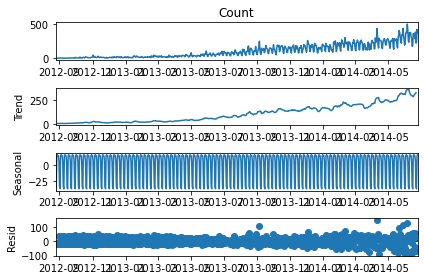

In [66]:
#Lets visualize all these parts.

import statsmodels.api as sm 
sm.tsa.seasonal_decompose(Train.Count).plot() 
result = sm.tsa.stattools.adfuller(train.Count) 
plt.show()

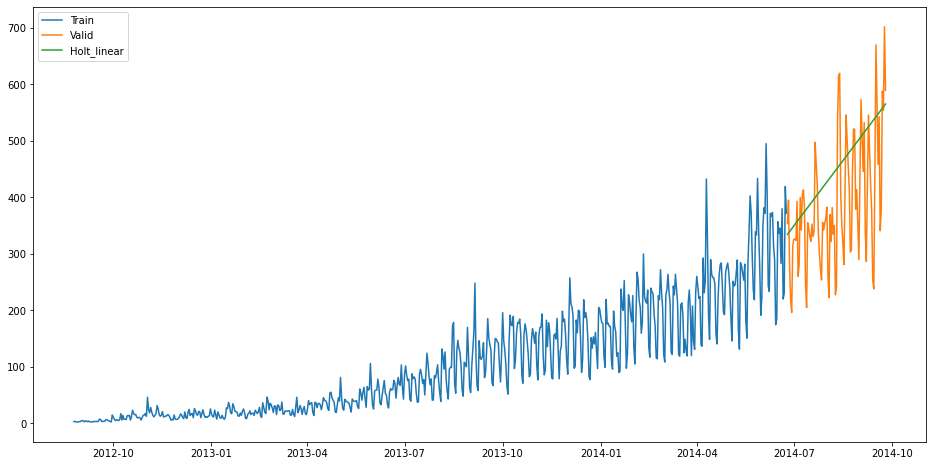

In [67]:
#An increasing trend can be seen in the dataset, so now we will make a model based on the trend.

y_hat_avg = valid.copy() 
fit1 = Holt(np.asarray(Train['Count'])).fit(smoothing_level = 0.3,smoothing_slope = 0.1) 
y_hat_avg['Holt_linear'] = fit1.forecast(len(valid)) 
plt.figure(figsize=(16,8)) 
plt.plot(Train['Count'], label='Train') 
plt.plot(valid['Count'], label='Valid') 
plt.plot(y_hat_avg['Holt_linear'], label='Holt_linear') 
plt.legend(loc='best') 
plt.show()

In [69]:
rms = sqrt(mean_squared_error(valid.Count, y_hat_avg.Holt_linear)) 
print(rms)

#(It can be inferred that the rmse value has decreased.)

112.94278345314041


In [70]:
#3) Holt’s Linear Trend Model on daily time series

#Now let’s try to make holt’s linear trend model on the daily time series and make predictions on the test dataset.
#We will make predictions based on the daily time series and then will distribute that daily prediction to hourly predictions.
#We have fitted the holt’s linear trend model on the train dataset and validated it using validation dataset.

In [76]:
#Now let’s load the submission file.

submission=pd.read_csv(r"C:\Users\Aditi\Traffic_prediction_using_Time_Series\sample_submission_LSeus50.csv")

In [77]:
#We only need ID and corresponding Count for the final submission.Let’s make prediction for the test dataset.

predict=fit1.forecast(len(test))

In [78]:
predict

array([334.65076685, 337.15901127, 339.66725568, 342.1755001 ,
       344.68374451, 347.19198892, 349.70023334, 352.20847775,
       354.71672217, 357.22496658, 359.73321099, 362.24145541,
       364.74969982, 367.25794424, 369.76618865, 372.27443307,
       374.78267748, 377.29092189, 379.79916631, 382.30741072,
       384.81565514, 387.32389955, 389.83214396, 392.34038838,
       394.84863279, 397.35687721, 399.86512162, 402.37336604,
       404.88161045, 407.38985486, 409.89809928, 412.40634369,
       414.91458811, 417.42283252, 419.93107694, 422.43932135,
       424.94756576, 427.45581018, 429.96405459, 432.47229901,
       434.98054342, 437.48878783, 439.99703225, 442.50527666,
       445.01352108, 447.52176549, 450.03000991, 452.53825432,
       455.04649873, 457.55474315, 460.06298756, 462.57123198,
       465.07947639, 467.58772081, 470.09596522, 472.60420963,
       475.11245405, 477.62069846, 480.12894288, 482.63718729,
       485.1454317 , 487.65367612, 490.16192053, 492.67

In [79]:
#Let’s save these predictions in test file in a new column.

test['prediction']=predict

In [80]:
test

,ID,year,month,day,Hour,prediction
Datetime,,,,,,
2014-09-26,18299.5,2014.0,9.0,26.0,11.5,334.650767
2014-09-27,18323.5,2014.0,9.0,27.0,11.5,337.159011
2014-09-28,18347.5,2014.0,9.0,28.0,11.5,339.667256
2014-09-29,18371.5,2014.0,9.0,29.0,11.5,342.175500
2014-09-30,18395.5,2014.0,9.0,30.0,11.5,344.683745
...,...,...,...,...,...,...
2015-04-22,23291.5,2015.0,4.0,22.0,11.5,856.365605
2015-04-23,23315.5,2015.0,4.0,23.0,11.5,858.873849
2015-04-24,23339.5,2015.0,4.0,24.0,11.5,861.382094


In [81]:
#Remember this is the daily predictions. We have to convert these predictions to hourly basis. 
#* To do so we will first calculate the ratio of passenger count for each hour of every day. 
#* Then we will find the average ratio of passenger count for every hour and we will get 24 ratios. 
#* Then to calculate the hourly predictions we will multiply the daily prediction with the hourly ratio.

In [82]:
#Calculating the hourly ratio of count 

train_original['ratio']=train_original['Count']/train_original['Count'].sum() 

In [83]:
# Grouping the hourly ratio 

temp=train_original.groupby(['Hour'])['ratio'].sum() 

In [85]:
# Groupby to csv format 

pd.DataFrame(temp, columns=['Hour','ratio']).to_csv('GROUPby.csv') 

In [86]:
temp2=pd.read_csv("GROUPby.csv") 
temp2=temp2.drop('Hour.1',1) 

In [87]:
# Merge Test and test_original on day, month and year 

merge=pd.merge(test, test_original, on=('day','month', 'year'), how='left') 
merge['Hour']=merge['Hour_y'] 
merge=merge.drop(['year', 'month', 'Datetime','Hour_x','Hour_y'], axis=1) 

In [88]:
# Predicting by merging merge and temp2 

prediction=pd.merge(merge, temp2, on='Hour', how='left') 

In [89]:
prediction

,ID_x,day,prediction,ID_y,Hour,ratio
0,18299.5,26.0,334.650767,18288,0,0.044287
1,18299.5,26.0,334.650767,18289,1,0.035343
2,18299.5,26.0,334.650767,18290,2,0.029911
3,18299.5,26.0,334.650767,18291,3,0.024714
4,18299.5,26.0,334.650767,18292,4,0.020802
...,...,...,...,...,...,...
5107,23387.5,26.0,866.398583,23395,19,0.055627
5108,23387.5,26.0,866.398583,23396,20,0.053455
5109,23387.5,26.0,866.398583,23397,21,0.049895
5110,23387.5,26.0,866.398583,23398,22,0.050076


In [91]:
# Converting the ratio to the original scale 

prediction['Count']=prediction['prediction']*prediction['ratio']*24
prediction['ID']=prediction['ID_y']

In [92]:
#Let’s drop all other features from the submission file and keep ID and Count only.

submission=prediction.drop(['ID_x', 'day', 'ID_y','prediction','Hour', 'ratio'],axis=1) 

In [93]:
# Converting the final submission to csv format 

pd.DataFrame(submission, columns=['ID','Count']).to_csv('Holt linear.csv')

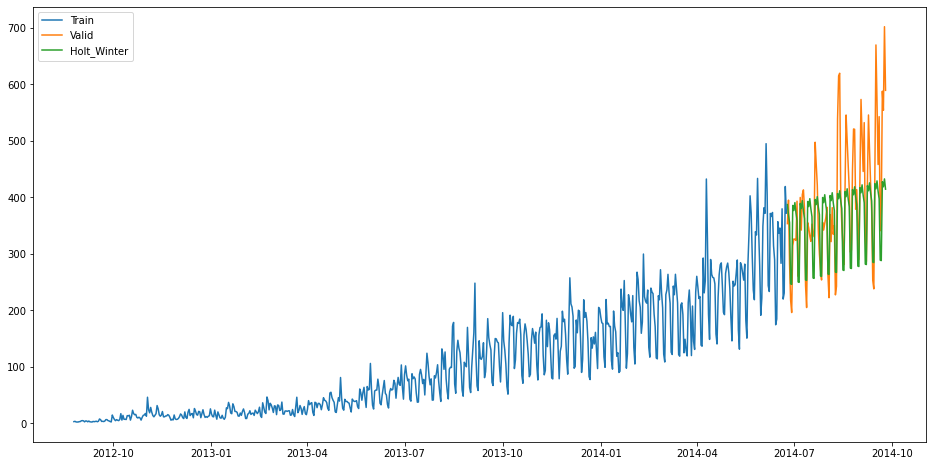

In [94]:
#4) Holt winter’s model on daily time series

y_hat_avg = valid.copy() 
fit1 = ExponentialSmoothing(np.asarray(Train['Count']) ,seasonal_periods=7 ,trend='add', seasonal='add',).fit() 
y_hat_avg['Holt_Winter'] = fit1.forecast(len(valid)) 
plt.figure(figsize=(16,8)) 
plt.plot( Train['Count'], label='Train') 
plt.plot(valid['Count'], label='Valid') 
plt.plot(y_hat_avg['Holt_Winter'], label='Holt_Winter') 
plt.legend(loc='best') 
plt.show()

In [95]:
rms = sqrt(mean_squared_error(valid.Count, y_hat_avg.Holt_Winter)) 
print(rms)

82.34683404090167


In [96]:
predict=fit1.forecast(len(test))

#Now we will convert these daily passenger count into hourly passenger count using the same approach which we followed above.

test['prediction']=predict

In [98]:
# Merge Test and test_original on day, month and year 

merge=pd.merge(test, test_original, on=('day','month', 'year'), how='left') 
merge['Hour']=merge['Hour_y'] 
merge=merge.drop(['year', 'month', 'Datetime','Hour_x','Hour_y'], axis=1) 

In [99]:
# Predicting by merging merge and temp2 

prediction=pd.merge(merge, temp2, on='Hour', how='left') 

In [100]:
# Converting the ratio to the original scale 
    
prediction['Count']=prediction['prediction']*prediction['ratio']*24

In [101]:
#Let’s drop all features other than ID and Count

prediction['ID']=prediction['ID_y'] 
submission=prediction.drop(['day','Hour','ratio','prediction', 'ID_x', 'ID_y'],axis=1)

In [102]:
# Converting the final submission to csv format 

pd.DataFrame(submission, columns=['ID','Count']).to_csv('Holt winters.csv')

In [127]:
#6) Parameter tuning for ARIMA model

#Stationarity Check

from statsmodels.tsa.stattools import adfuller 
def test_stationarity(timeseries):
    
        #Determing rolling statistics
    rolmean = timeseries.rolling(24).mean()
    rolstd = timeseries.rolling(24).std()
    
        #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
        #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

    

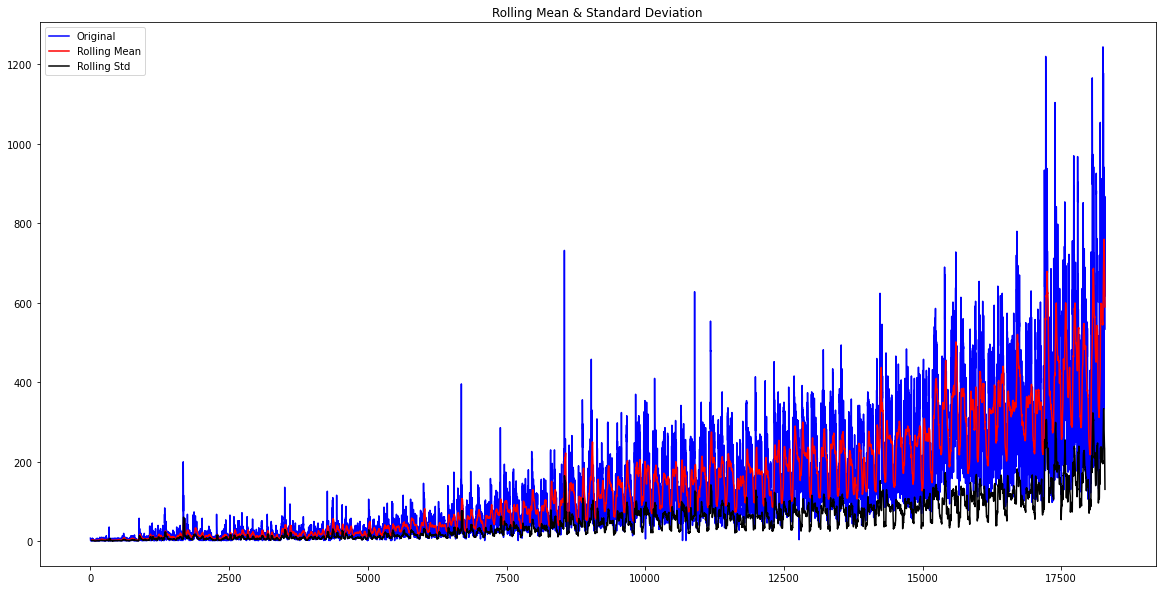

Results of Dickey-Fuller Test:
Test Statistic                    -4.456561
p-value                            0.000235
#Lags Used                        45.000000
Number of Observations Used    18242.000000
Critical Value (1%)               -3.430709
Critical Value (5%)               -2.861698
Critical Value (10%)              -2.566854
dtype: float64


In [128]:
from matplotlib.pylab import rcParams 
rcParams['figure.figsize'] = 20,10
test_stationarity(train_original['Count'])

In [129]:
#Removing Trend

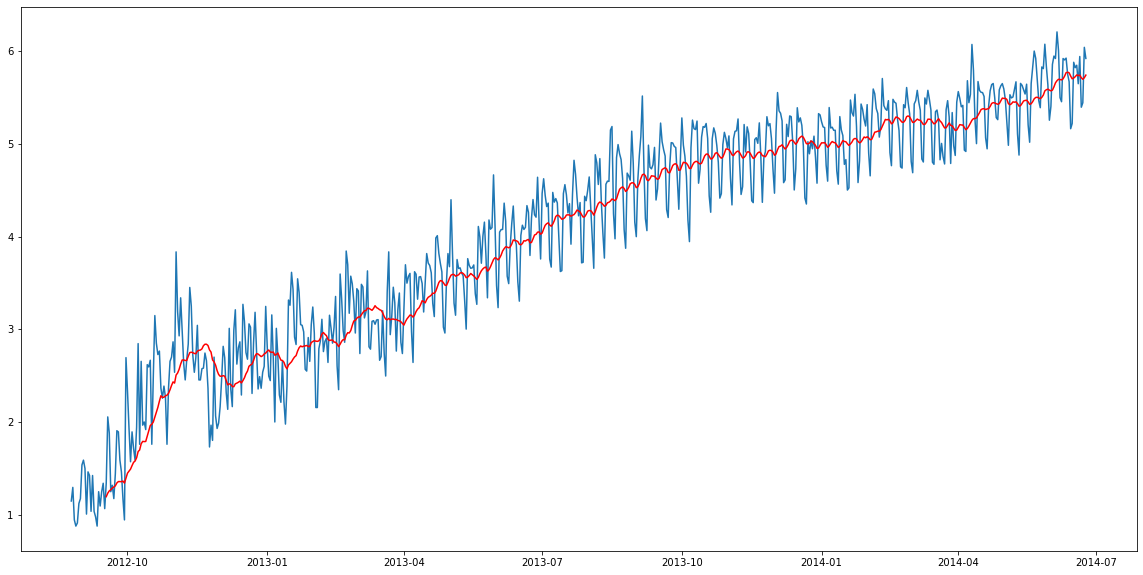

In [132]:
Train_log = np.log(Train['Count']) 
valid_log = np.log(valid['Count'])
moving_avg = Train_log.rolling(24).mean() 
plt.plot(Train_log) 
plt.plot(moving_avg, color = 'red') 
plt.show()

In [133]:
#So we can observe an increasing trend. Now we will remove this increasing trend to make our time series stationary.

train_log_moving_avg_diff = Train_log - moving_avg

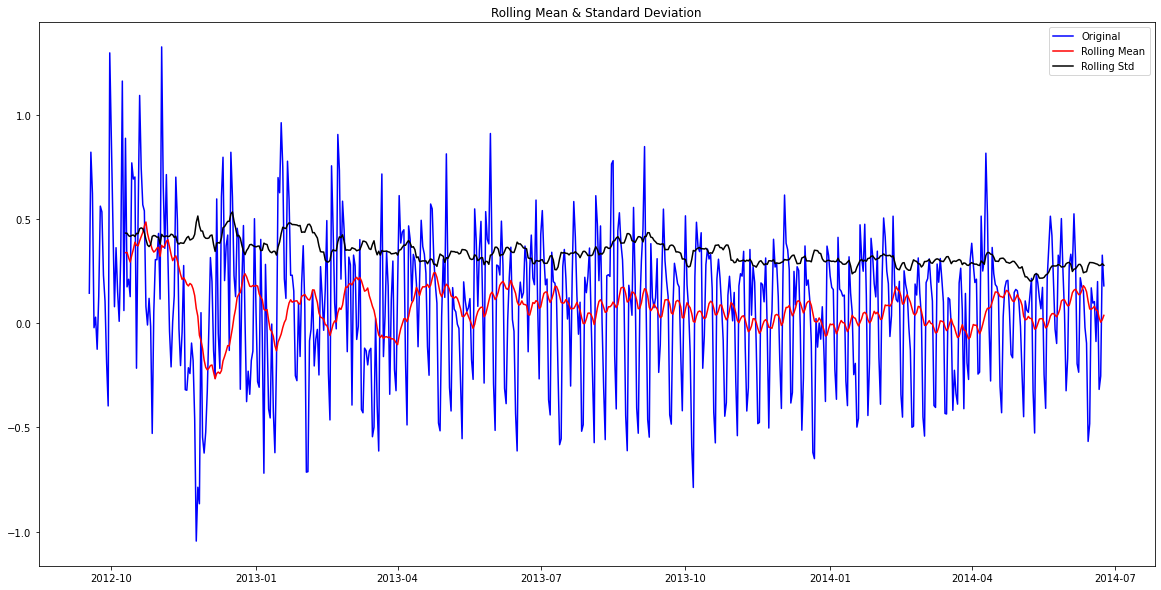

Results of Dickey-Fuller Test:
Test Statistic                -5.861646e+00
p-value                        3.399422e-07
#Lags Used                     2.000000e+01
Number of Observations Used    6.250000e+02
Critical Value (1%)           -3.440856e+00
Critical Value (5%)           -2.866175e+00
Critical Value (10%)          -2.569239e+00
dtype: float64


In [135]:
#Since we took the average of 24 values, rolling mean is not defined for the first 23 values. So let’s drop those null values.

train_log_moving_avg_diff.dropna(inplace = True) 
test_stationarity(train_log_moving_avg_diff)

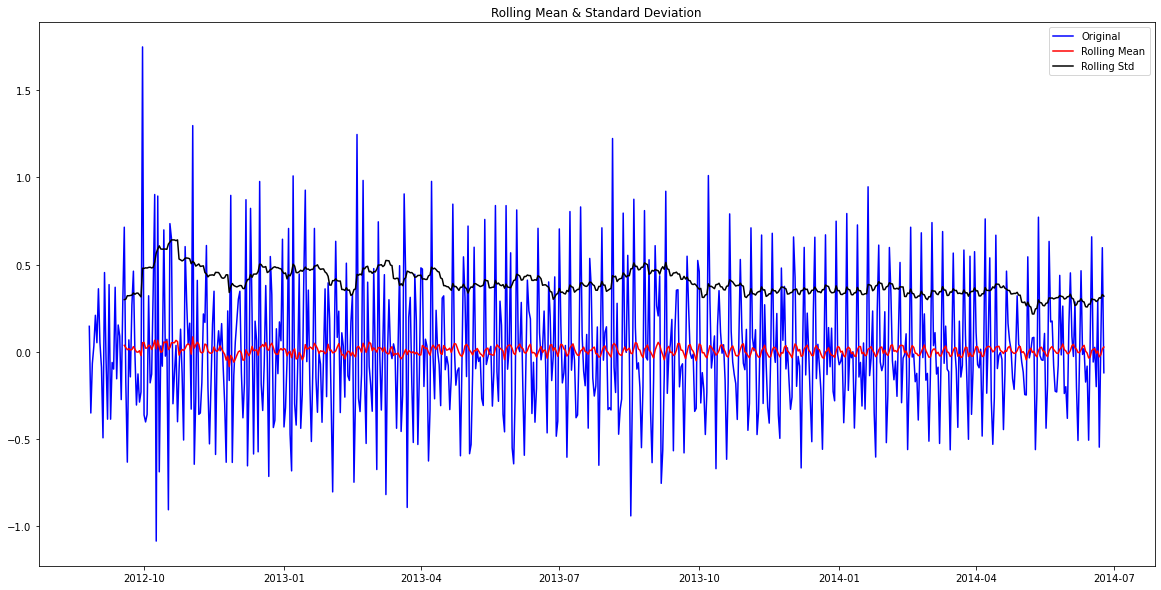

Results of Dickey-Fuller Test:
Test Statistic                -8.237568e+00
p-value                        5.834049e-13
#Lags Used                     1.900000e+01
Number of Observations Used    6.480000e+02
Critical Value (1%)           -3.440482e+00
Critical Value (5%)           -2.866011e+00
Critical Value (10%)          -2.569151e+00
dtype: float64


In [136]:
#Let’s now stabilize the mean of the time series which is also a requirement for a stationary time series.
#Differencing can help to make the series stable and eliminate the trend.

train_log_diff = Train_log - Train_log.shift(1) 
test_stationarity(train_log_diff.dropna())

In [137]:
#Removing Seasonality

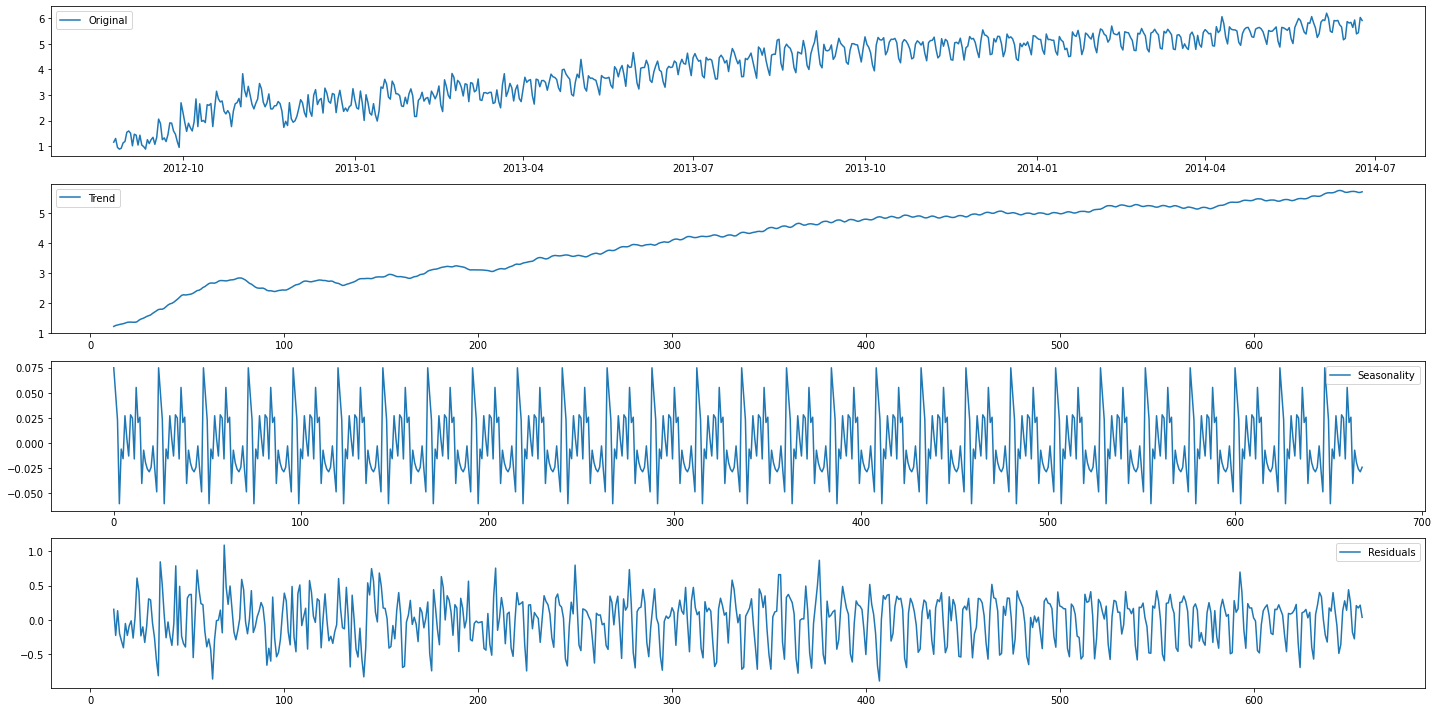

In [139]:
from statsmodels.tsa.seasonal import seasonal_decompose 
decomposition = seasonal_decompose(pd.DataFrame(Train_log).Count.values, period = 24) 

trend = decomposition.trend 
seasonal = decomposition.seasonal 
residual = decomposition.resid 

plt.subplot(411) 
plt.plot(Train_log, label='Original') 
plt.legend(loc='best') 
plt.subplot(412) 
plt.plot(trend, label='Trend') 
plt.legend(loc='best') 
plt.subplot(413) 
plt.plot(seasonal,label='Seasonality') 
plt.legend(loc='best') 
plt.subplot(414) 
plt.plot(residual, label='Residuals') 
plt.legend(loc='best') 
plt.tight_layout() 
plt.show()

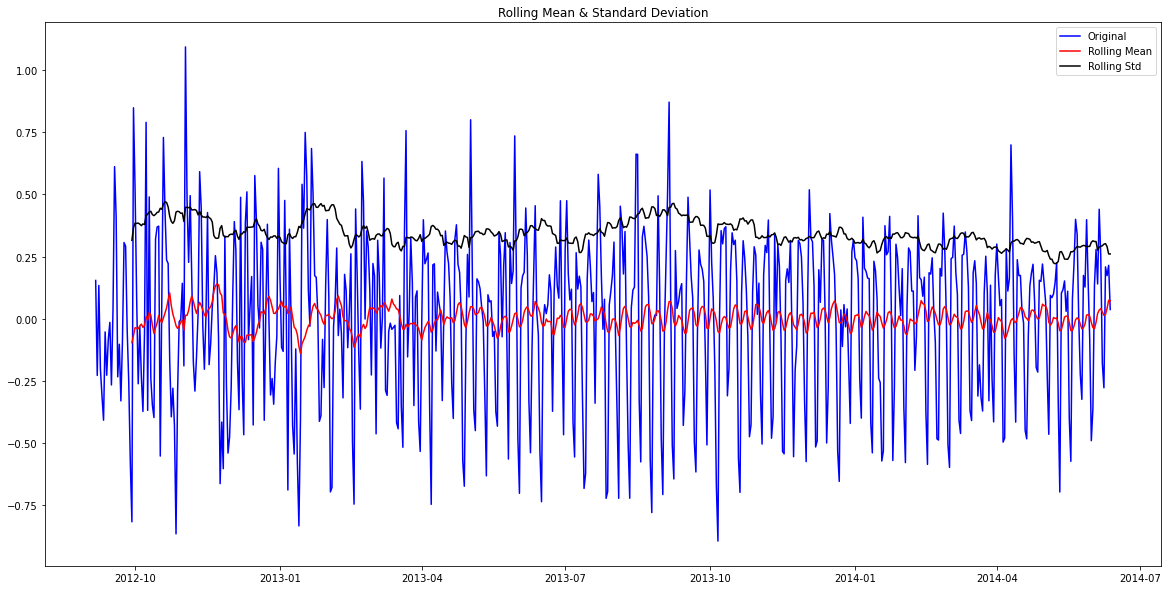

Results of Dickey-Fuller Test:
Test Statistic                -7.822096e+00
p-value                        6.628321e-12
#Lags Used                     2.000000e+01
Number of Observations Used    6.240000e+02
Critical Value (1%)           -3.440873e+00
Critical Value (5%)           -2.866183e+00
Critical Value (10%)          -2.569243e+00
dtype: float64


In [141]:
#Seasonality shows a constant trend in counter.
#Let’s check stationarity of residuals.

train_log_decompose = pd.DataFrame(residual) 
train_log_decompose['date'] = Train_log.index 
train_log_decompose.set_index('date', inplace = True) 
train_log_decompose.dropna(inplace=True) 
test_stationarity(train_log_decompose[0])

#(It can be interpreted from the results that the residuals are stationary.)

In [142]:
#Forecasting the time series using ARIMA

In [143]:
from statsmodels.tsa.stattools import acf, pacf 
lag_acf = acf(train_log_diff.dropna(), nlags=25) 
lag_pacf = pacf(train_log_diff.dropna(), nlags=25, method='ols')

c:\users\aditi\appdata\local\programs\python\python36\lib\site-packages\statsmodels\tsa\stattools.py:572: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  FutureWarning


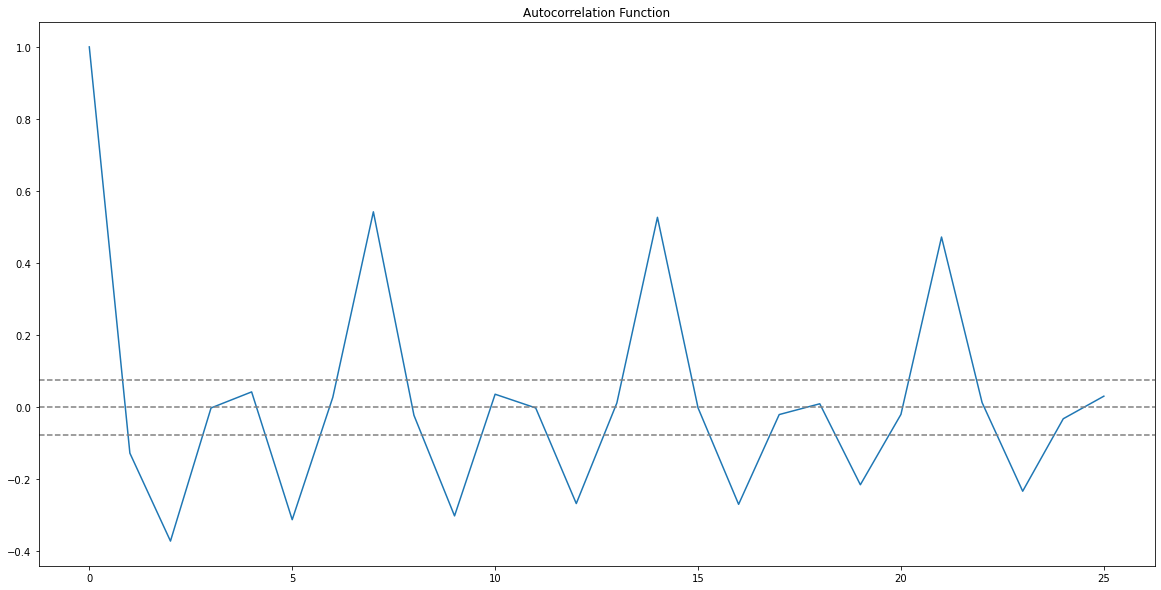

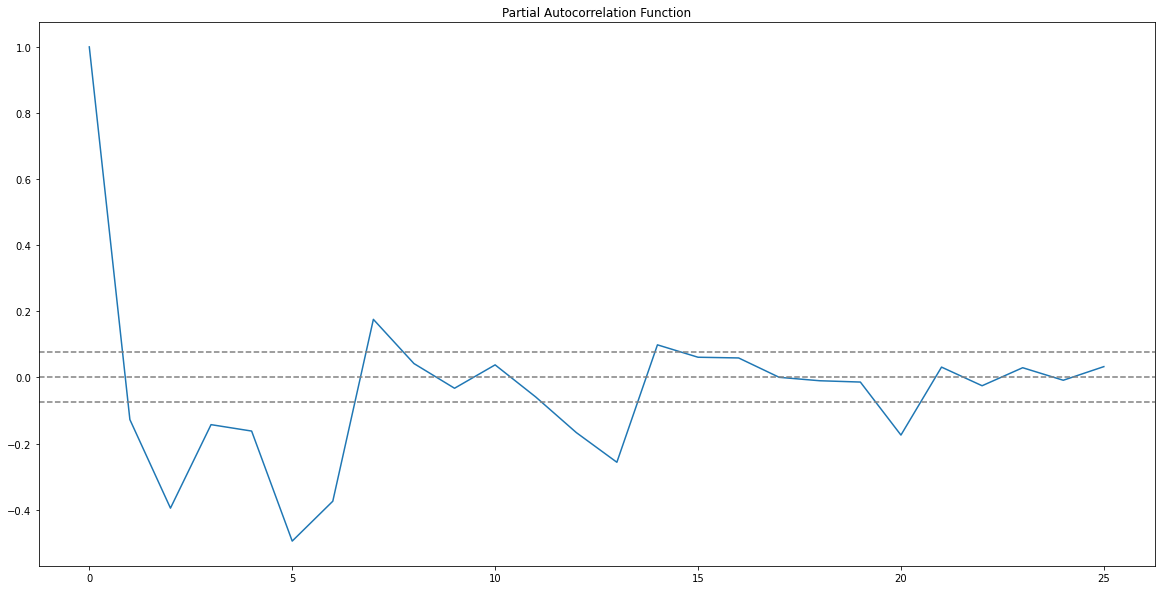

In [145]:
#ACF and PACF plot

plt.plot(lag_acf) 
plt.axhline(y=0,linestyle='--',color='gray') 
plt.axhline(y=-1.96/np.sqrt(len(train_log_diff.dropna())),linestyle='--',color='gray') 
plt.axhline(y=1.96/np.sqrt(len(train_log_diff.dropna())),linestyle='--',color='gray') 
plt.title('Autocorrelation Function') 
plt.show() 
plt.plot(lag_pacf) 
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(train_log_diff.dropna())),linestyle='--',color='gray') 
plt.axhline(y=1.96/np.sqrt(len(train_log_diff.dropna())),linestyle='--',color='gray') 
plt.title('Partial Autocorrelation Function') 
plt.show()

In [146]:
#p value is the lag value where the PACF chart crosses the upper confidence interval for the first time. 
#It can be noticed that in this case p=1.
#q value is the lag value where the ACF chart crosses the upper confidence interval for the first time. 
#It can be noticed that in this case q=1.
#Now we will make the ARIMA model as we have the p,q values. 
#We will make the AR and MA model separately and then combine them together.

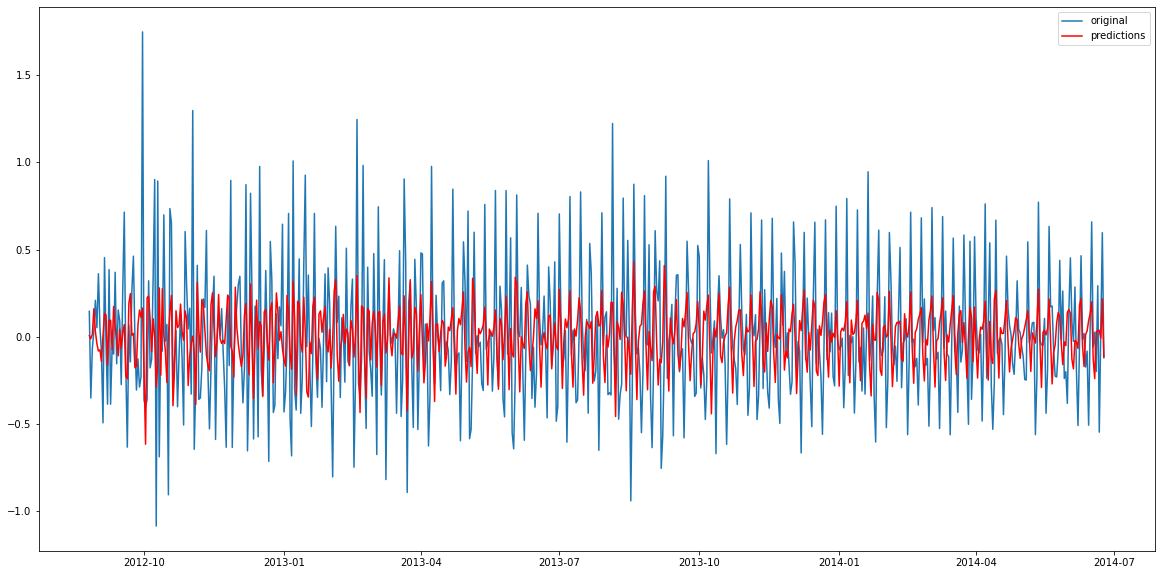

In [147]:
#AR model
#The autoregressive model specifies that the output variable depends linearly on its own previous values.

from statsmodels.tsa.arima_model import ARIMA
model = ARIMA(Train_log, order=(2, 1, 0))  # here the q value is zero since it is just the AR model 
results_AR = model.fit(disp=-1)  
plt.plot(train_log_diff.dropna(), label='original') 
plt.plot(results_AR.fittedvalues, color='red', label='predictions') 
plt.legend(loc='best') 
plt.show()

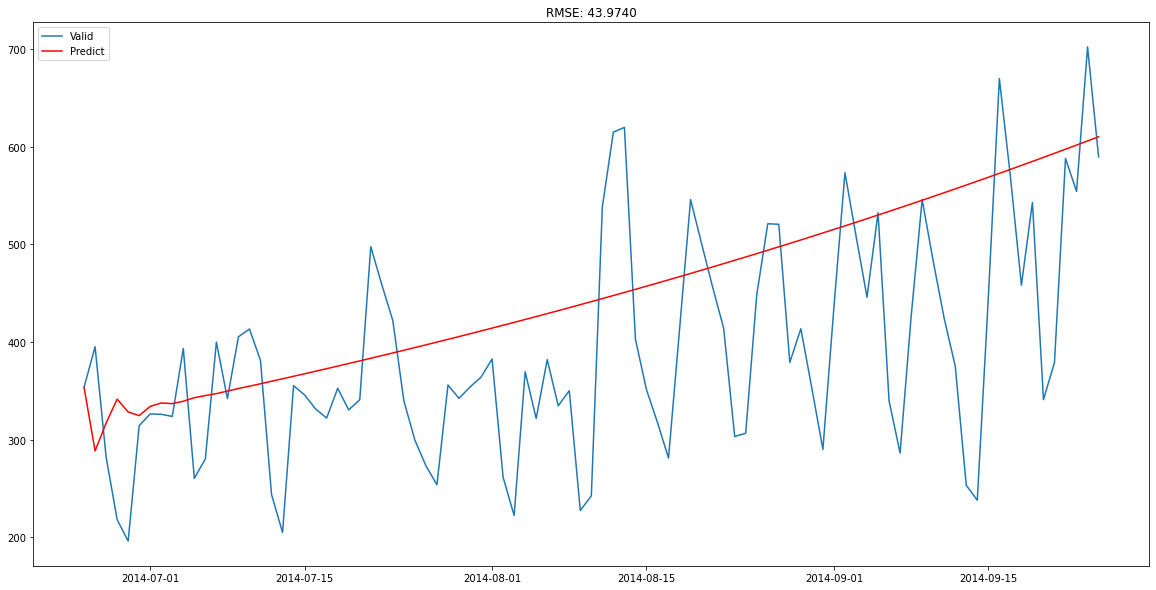

In [149]:
#Lets plot the validation curve for AR model.
#We have to change the scale of the model to the original scale.
#First step would be to store the predicted results as a separate series and observe it.

AR_predict=results_AR.predict(start="2014-06-25", end="2014-09-25") 
AR_predict=AR_predict.cumsum().shift().fillna(0) 
AR_predict1=pd.Series(np.ones(valid.shape[0]) * np.log(valid['Count'])[0], index = valid.index) 
AR_predict1=AR_predict1.add(AR_predict,fill_value=0) 
AR_predict = np.exp(AR_predict1)
plt.plot(valid['Count'], label = "Valid") 
plt.plot(AR_predict, color = 'red', label = "Predict") 
plt.legend(loc= 'best') 
plt.title('RMSE: %.4f'% (np.sqrt(np.dot(AR_predict, valid['Count']))/valid.shape[0])) 
plt.show()

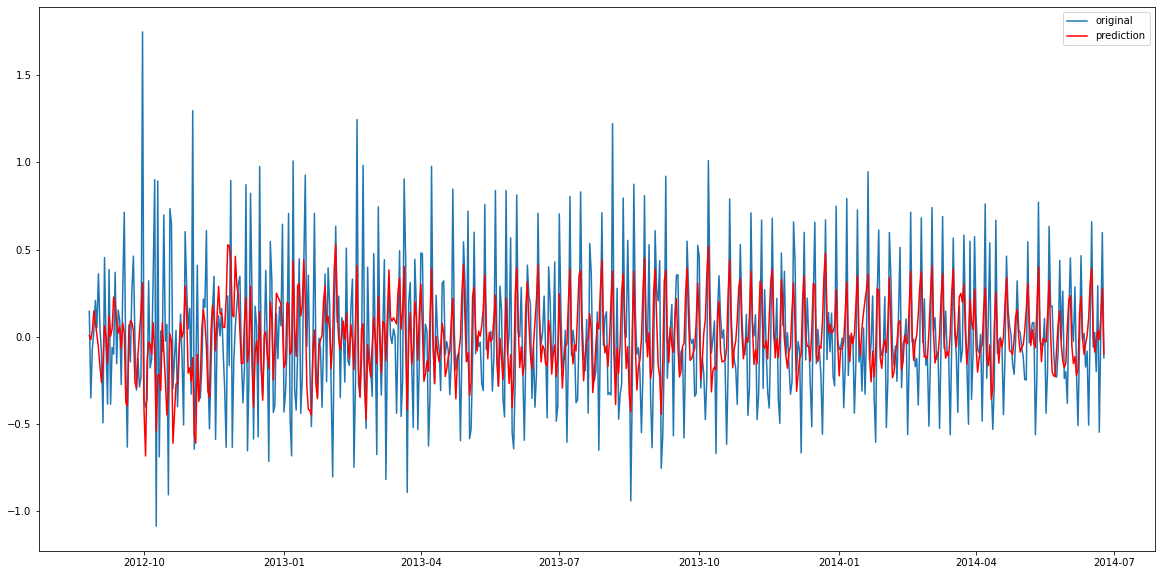

In [150]:
#MA model
#The moving-average model specifies that the output variable depends linearly on the current and various past values of a stochastic (imperfectly predictable) term.

model = ARIMA(Train_log, order=(0, 1, 2))  # here the p value is zero since it is just the MA model 
results_MA = model.fit(disp=-1)  
plt.plot(train_log_diff.dropna(), label='original') 
plt.plot(results_MA.fittedvalues, color='red', label='prediction') 
plt.legend(loc='best') 
plt.show()

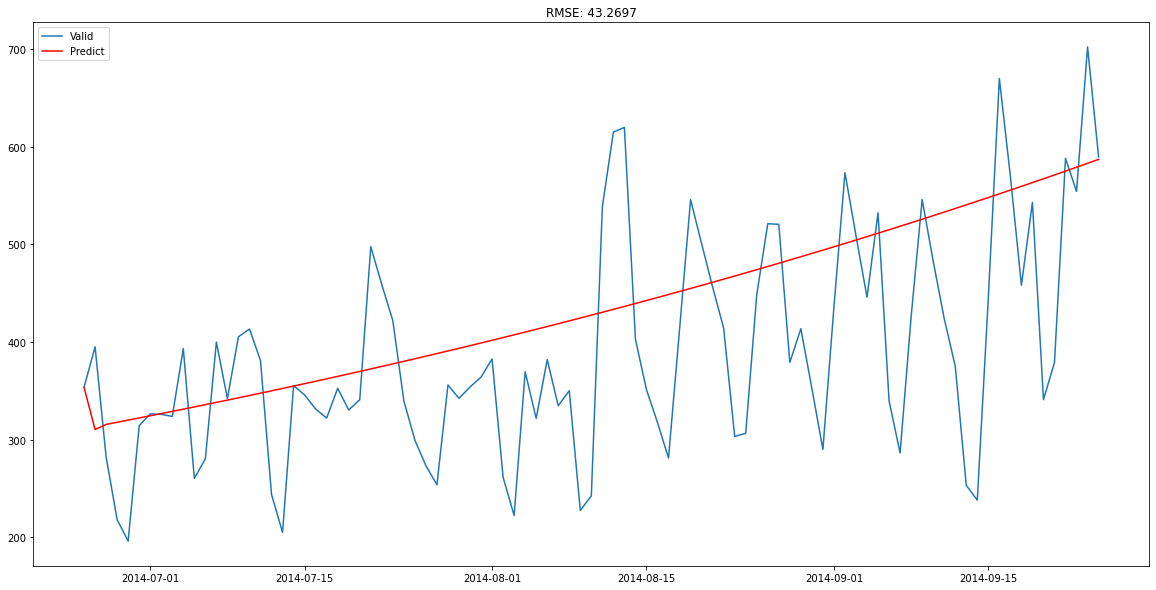

In [151]:
MA_predict=results_MA.predict(start="2014-06-25", end="2014-09-25") 
MA_predict=MA_predict.cumsum().shift().fillna(0) 
MA_predict1=pd.Series(np.ones(valid.shape[0]) * np.log(valid['Count'])[0], index = valid.index) 
MA_predict1=MA_predict1.add(MA_predict,fill_value=0) 
MA_predict = np.exp(MA_predict1)
plt.plot(valid['Count'], label = "Valid") 
plt.plot(MA_predict, color = 'red', label = "Predict") 
plt.legend(loc= 'best') 
plt.title('RMSE: %.4f'% (np.sqrt(np.dot(MA_predict, valid['Count']))/valid.shape[0])) 
plt.show()

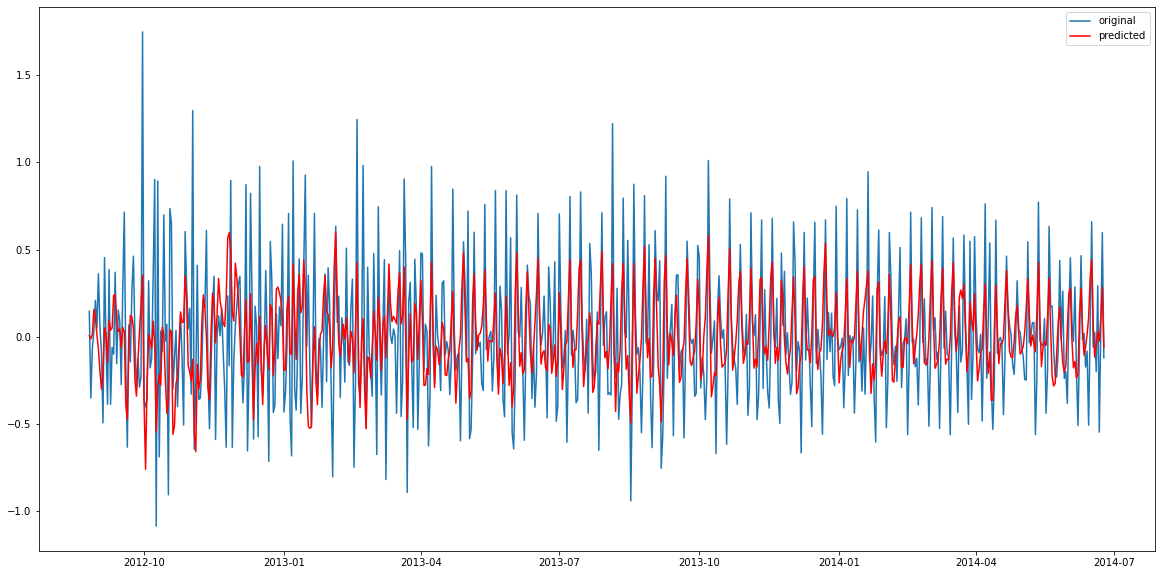

In [152]:
#Combined model

model = ARIMA(Train_log, order=(2, 1, 2))  
results_ARIMA = model.fit(disp=-1)  
plt.plot(train_log_diff.dropna(),  label='original') 
plt.plot(results_ARIMA.fittedvalues, color='red', label='predicted') 
plt.legend(loc='best') 
plt.show()

In [156]:
#Let’s define a function which can be used to change the scale of the model to the original scale.

def check_prediction_diff(predict_diff, given_set):
    predict_diff= predict_diff.cumsum().shift().fillna(0)
    predict_base = pd.Series(np.ones(given_set.shape[0]) * np.log(given_set['Count'])[0], index = given_set.index)
    predict_log = predict_base.add(predict_diff,fill_value=0)
    predict = np.exp(predict_log)
    
    plt.plot(given_set['Count'], label = "Given set")
    plt.plot(predict, color = 'red', label = "Predict")
    plt.legend(loc= 'best')
    plt.title('RMSE: %.4f'% (np.sqrt(np.dot(predict, given_set['Count']))/given_set.shape[0]))
    plt.show()

In [157]:
def check_prediction_log(predict_log, given_set):
    predict = np.exp(predict_log)
 
    plt.plot(given_set['Count'], label = "Given set")
    plt.plot(predict, color = 'red', label = "Predict")
    plt.legend(loc= 'best')
    plt.title('RMSE: %.4f'% (np.sqrt(np.dot(predict, given_set['Count']))/given_set.shape[0]))
    plt.show()

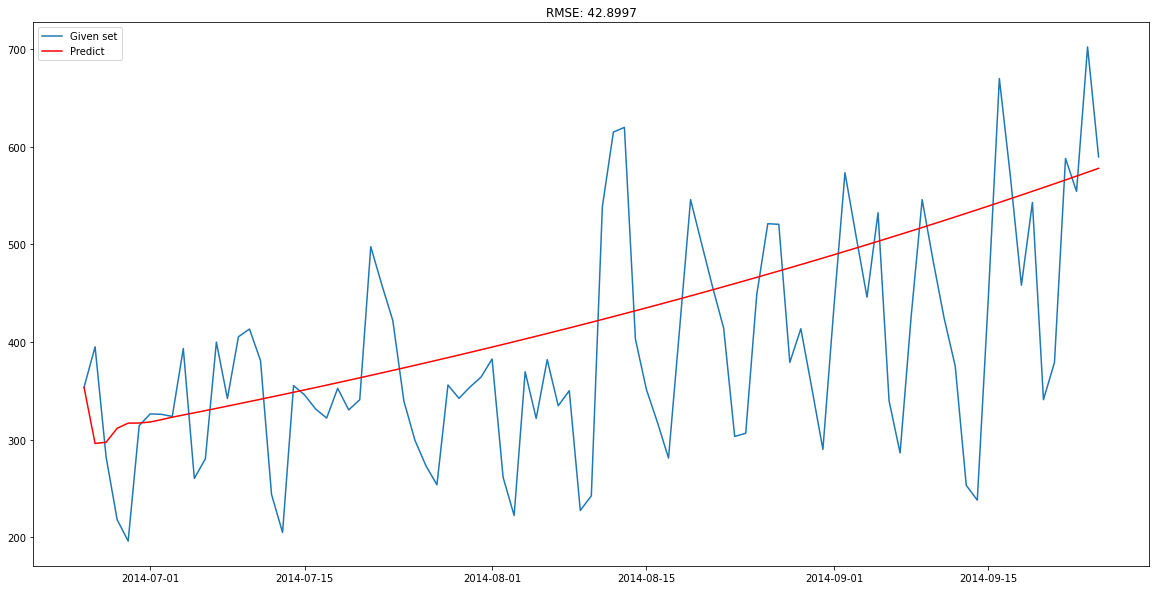

In [158]:
#Let’s predict the values for validation set.

ARIMA_predict_diff=results_ARIMA.predict(start="2014-06-25", end="2014-09-25")
check_prediction_diff(ARIMA_predict_diff, valid)

In [159]:
#7) SARIMAX model on daily time series

c:\users\aditi\appdata\local\programs\python\python36\lib\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)


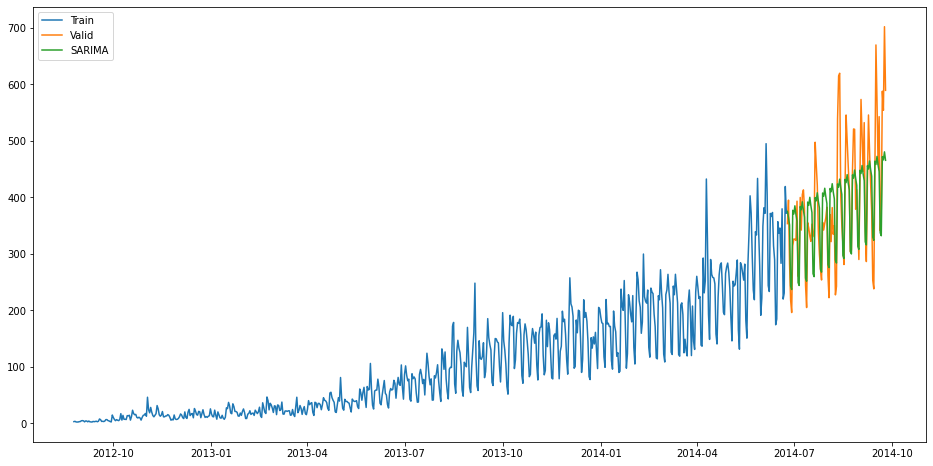

In [161]:
y_hat_avg = valid.copy() 
fit1 = sm.tsa.statespace.SARIMAX(Train.Count, order=(2, 1, 4),seasonal_order=(0,1,1,7)).fit() 
y_hat_avg['SARIMA'] = fit1.predict(start="2014-6-25", end="2014-9-25", dynamic=True) 
plt.figure(figsize=(16,8)) 
plt.plot( Train['Count'], label='Train') 
plt.plot(valid['Count'], label='Valid') 
plt.plot(y_hat_avg['SARIMA'], label='SARIMA') 
plt.legend(loc='best') 
plt.show()

In [162]:
#In our case the periodicity is 7 since it is daily time series and will repeat after every 7 days.
#Let’s check the rmse value for the validation part.

rms = sqrt(mean_squared_error(valid.Count, y_hat_avg.SARIMA)) 
print(rms)

69.89944919787027


In [168]:
#Now we will forecast the time series for Test data which starts from 2014-9-26 and ends at 2015-4-26.

predict=fit1.predict(start="2014-9-26", end="2015-4-26", dynamic=True)

test['prediction']=predict
# Merge Test and test_original on day, month and year 
merge=pd.merge(test, test_original, on=('day','month', 'year'), how='left') 
merge['Hour']=merge['Hour_y'] 
merge=merge.drop(['year', 'month', 'Datetime','Hour_x','Hour_y'], axis=1) 

# Predicting by merging merge and temp2 
prediction=pd.merge(merge, temp2, on='Hour', how='left') 

# Converting the ratio to the original scale
prediction['Count']=prediction['prediction']*prediction['ratio']*24

#Let’s drop all variables other than ID and Count

prediction['ID']=prediction['ID_y'] 
submission=prediction.drop(['day','Hour','ratio','prediction', 'ID_x', 'ID_y'],axis=1) 

# Converting the final submission to csv format 
pd.DataFrame(submission, columns=['ID','Count']).to_csv('SARIMAX.csv')

c:\users\aditi\appdata\local\programs\python\python36\lib\site-packages\statsmodels\tsa\statespace\kalman_filter.py:2014: ValueWarning: Dynamic prediction specified to begin during out-of-sample forecasting period, and so has no effect.
  ' effect.', ValueWarning)


In [169]:
#This method gave us the least rmse score. The rmse on the leaderboard was 219.095.